## 2장 1강: 선형 회귀 모델과 오차 평가지표
### 3. 주택 가격 예측 선형 회귀 구현
#### 3.1 데이터 불러오기 및 확인

USA 주택 데이터(CSV) 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('usa_housing.csv')
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


데이터 전처리: 최근 데이터 + 범죄율이 낮은 데이터로 필터링

In [2]:
df = df[(df['YearBuilt'] > 2015) & (df['CrimeRate'] < 40)]

df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
9,737147,3,2.6,4191,2017,0,1.65,66549,37.60,3
33,586232,4,1.3,3854,2021,2,1.39,30103,26.93,2
112,616588,2,1.2,3872,2016,0,0.17,61112,20.98,8
119,979858,5,3.8,4307,2020,0,0.38,41822,37.14,4
189,161087,5,2.4,964,2021,1,0.24,34022,12.80,3


그래프로 데이터 분포 확인하기

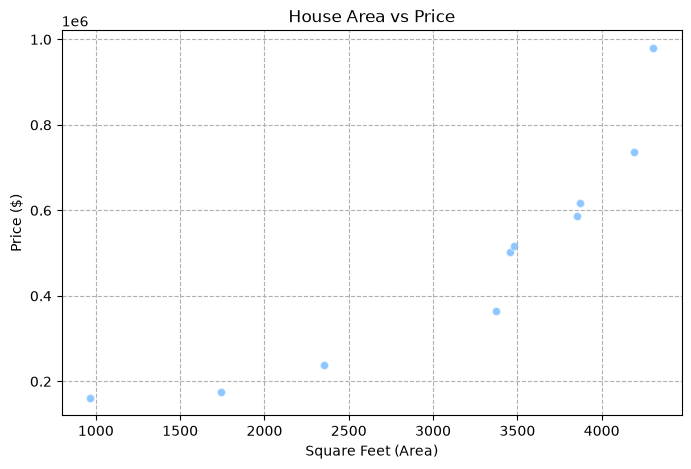

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df['SquareFeet'], df['Price'], color='dodgerblue', alpha=0.5, edgecolor='w')
plt.title('House Area vs Price')
plt.xlabel('Square Feet (Area)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--')
plt.show()

#### 3.2 모델 학습 및 결과 시각화

특성(Feature, 방 면적)과 정답(Label, 집값) 나누기

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import sklearn
sklearn.set_config(display="text")

X = df[['SquareFeet']].values
y = df['Price'].values
X.shape, y.shape


((10, 1), (10,))

선형 회귀 모델 준비 및 학습(fit)

= fit(특성(Feature), 정답(Label)) : 학습을 진행

In [32]:
model = LinearRegression()
model.fit(X, y)

print(model.coef_, model.intercept_)

[210.23217333] -176577.39806530828


학습된 모델로 집값 예측해보기

- predict(..) : 예측

In [26]:
y_pred = model.predict(X)

y_pred

array([704505.64035344, 633657.39794181, 637441.57706172, 728892.57245951,
        26086.41702314, 189857.28004585, 318519.37012275, 532535.72257092,
       550195.22513049, 555240.79729037])

오차 점수 확인하기

In [27]:
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("MSE:", mse)
print("MAE", mae)

MSE: 12374713026.514887
MAE 83721.47403278269


모델이 찾은 직선 그래프로 그려보기

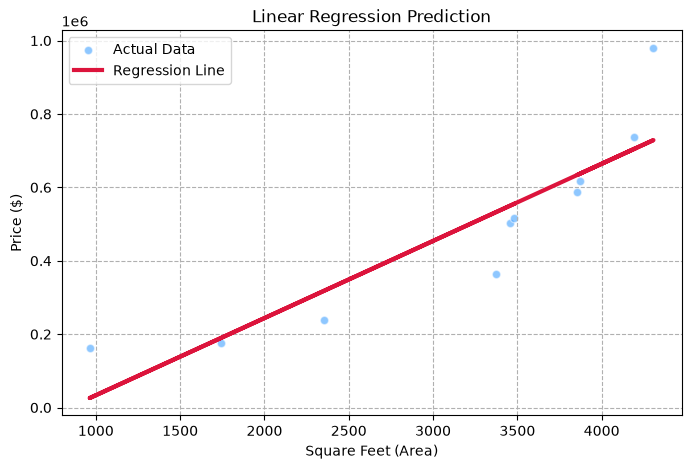

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='dodgerblue', alpha=0.5, edgecolor='w', label='Actual Data')
plt.plot(X, y_pred, color='crimson', linewidth=3, label='Regression Line')
plt.title('Linear Regression Prediction')
plt.xlabel('Square Feet (Area)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()